In [ ]:
# Cell 1: Mount Drive and show environment
# Explanation: mounts Google Drive and sets dataset/model paths to your existing folders.
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os, sys, platform
import tensorflow as tf
from pathlib import Path

print("Python:", sys.version.splitlines()[0])
print("Platform:", platform.platform())
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

DRIVE_ROOT = "/content/drive/MyDrive"
DATA_ROOT = os.path.join(DRIVE_ROOT, "newDataset")   # uses your unzipped folder
TRAINING_DIR = os.path.join(DATA_ROOT, "Training")
TEST_DIR     = os.path.join(DATA_ROOT, "Testing")
MODEL_DIR    = os.path.join(DATA_ROOT, "Model")
os.makedirs(MODEL_DIR, exist_ok=True)

print("TRAINING_DIR:", TRAINING_DIR)
print("TEST_DIR:", TEST_DIR)
print("MODEL_DIR:", MODEL_DIR)


Mounted at /content/drive
Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Platform: Linux-6.6.105+-x86_64-with-glibc2.35
TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TRAINING_DIR: /content/drive/MyDrive/newDataset/Training
TEST_DIR: /content/drive/MyDrive/newDataset/Testing
MODEL_DIR: /content/drive/MyDrive/newDataset/Model


In [ ]:
# Cell 2: Install optional libs and set config flags
# Explanation: installs nibabel/pydicom (if not present) and sets core hyperparameters + paths.
!pip install -q nibabel pydicom

import random, numpy as np, tensorflow as tf, os
random.seed(42); np.random.seed(42); tf.random.set_seed(42)

# Core config (edit if needed)
IMG_SIZE = (380, 380)   # EfficientNetB4 input
BATCH_SIZE = 20
NUM_CLASSES = 4
EPOCHS = 50             # train longer since no val-based early stopping on generalization
PATIENCE = 6            # early stopping on training loss (careful - see note)
PREPRO_ROOT = os.path.join(DATA_ROOT, "preprocessed")
MANIFEST_DIR = os.path.join(DATA_ROOT, "manifests")
os.makedirs(PREPRO_ROOT, exist_ok=True)
os.makedirs(MANIFEST_DIR, exist_ok=True)

# Preprocessing flags
APPLY_ZSCORE = True
CLIP_PERCENTILES = (1, 99)
IMG_FORMAT = "png"
SKIP_EXISTING = True

# Fine-tuning flags
FINE_TUNE_UNFREEZE_LAST = 50
LABEL_SMOOTHING = 0.08

print("Config:", "IMG_SIZE", IMG_SIZE, "BATCH_SIZE", BATCH_SIZE, "EPOCHS", EPOCHS)
print("PREPRO_ROOT:", PREPRO_ROOT)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 44.5 MB/s eta 0:00:00
Config: IMG_SIZE (380, 380) BATCH_SIZE 20 EPOCHS 50
PREPRO_ROOT: /content/drive/MyDrive/newDataset/preprocessed


In [ ]:
# Cell 3: Build manifests — NO patient-level validation; all training images marked 'train'
# Explanation: because your dataset has extremely few patients, we use all Training images for training.
import glob, pandas as pd, os
from pathlib import Path

def list_files_by_class(root):
    rows=[]
    if not os.path.isdir(root):
        return pd.DataFrame(rows)
    for cls in sorted(os.listdir(root)):
        cls_path = os.path.join(root, cls)
        if os.path.isdir(cls_path):
            for f in glob.glob(os.path.join(cls_path, "*")):
                if os.path.isfile(f):
                    rows.append({"filepath": os.path.abspath(f), "class": cls})
    return pd.DataFrame(rows)

train_df = list_files_by_class(TRAINING_DIR)
test_df  = list_files_by_class(TEST_DIR)

train_df['subset'] = "train"
test_df['subset'] = "test"

train_df.to_csv(os.path.join(MANIFEST_DIR, "train_manifest.csv"), index=False)
test_df.to_csv(os.path.join(MANIFEST_DIR, "test_manifest.csv"), index=False)

print("Training images:", len(train_df))
print("Testing images:", len(test_df))
print("Train per-class counts:")
print(train_df.groupby('class').size())
print("Test per-class counts:")
print(test_df.groupby('class').size())


Training images: 5712
Testing images: 1311
Train per-class counts:
class
glioma        1321
meningioma    1339
notumor       1595
pituitary     1457
dtype: int64
Test per-class counts:
class
glioma        300
meningioma    306
notumor       405
pituitary     300
dtype: int64


In [ ]:
# Cell 4: Offline preprocessing -> PREPRO_ROOT (reads png/jpg/dcm/nii -> writes normalized PNGs)
# Explanation: reads raw images/DICOM/NIfTI, clips percentiles, z-score (if enabled), converts to RGB and saves resized PNGs.
import os, numpy as np, pandas as pd
from PIL import Image
from pathlib import Path
import nibabel as nib, pydicom
from tqdm import tqdm

os.makedirs(PREPRO_ROOT, exist_ok=True)
train_manifest = pd.read_csv(os.path.join(MANIFEST_DIR, "train_manifest.csv"))
test_manifest  = pd.read_csv(os.path.join(MANIFEST_DIR, "test_manifest.csv"))
all_manifest = pd.concat([train_manifest, test_manifest], ignore_index=True)

def read_any(path):
    ext = Path(path).suffix.lower()
    if ext in [".png", ".jpg", ".jpeg"]:
        img = Image.open(path).convert('L')
        return np.array(img).astype(np.float32)
    if ext == ".dcm":
        try:
            ds = pydicom.dcmread(path, force=True)
            return ds.pixel_array.astype(np.float32)
        except:
            return None
    if ext in [".nii", ".nii.gz", ".gz"]:
        try:
            img = nib.load(path)
            data = img.get_fdata()
            if data.ndim >= 3:
                sl = data.shape[2]//2
                arr = data[:,:,sl]
            else:
                arr = data
            return np.array(arr).astype(np.float32)
        except:
            return None
    return None

def clip(arr, p1=1, p2=99):
    lo, hi = np.percentile(arr, [p1, p2])
    return np.clip(arr, lo, hi)

def zscore(arr):
    mu = arr.mean(); sd = arr.std() if arr.std()>0 else 1.0
    return (arr - mu) / sd

def save_png(arr, outpath):
    if APPLY_ZSCORE:
        mu = arr.mean(); sd = arr.std() if arr.std()>0 else 1.0
        scaled = 127 + (arr - mu)/ (sd + 1e-8) * 32.0
        arr_uint8 = np.clip(scaled, 0, 255).astype(np.uint8)
    else:
        mn, mx = arr.min(), arr.max()
        arr_uint8 = ((arr - mn)/(mx - mn + 1e-8)*255).astype(np.uint8)
    if arr_uint8.ndim==2:
        rgb = np.stack([arr_uint8]*3, axis=-1)
    else:
        if arr_uint8.shape[-1] >= 3:
            rgb = arr_uint8[..., :3]
        else:
            rgb = np.stack([arr_uint8[...,0]]*3, axis=-1)
    pil = Image.fromarray(rgb)
    pil = pil.resize((IMG_SIZE[1], IMG_SIZE[0]), resample=Image.BILINEAR)
    pil.save(outpath, format=IMG_FORMAT)

rows = []
for _, row in tqdm(all_manifest.iterrows(), total=len(all_manifest)):
    src = row['filepath']; cls = row['class']; subset = row.get('subset','train')
    dst_dir = os.path.join(PREPRO_ROOT, subset, cls); os.makedirs(dst_dir, exist_ok=True)
    dst_name = Path(src).stem + "." + IMG_FORMAT
    dst_path = os.path.join(dst_dir, dst_name)
    if SKIP_EXISTING and os.path.exists(dst_path):
        rows.append({"original": src, "preprocessed": dst_path, "class": cls, "subset": subset})
        continue
    arr = read_any(src)
    if arr is None:
        print("Unreadable:", src); continue
    arr = clip(arr, CLIP_PERCENTILES[0], CLIP_PERCENTILES[1])
    if APPLY_ZSCORE:
        arr = zscore(arr)
    try:
        save_png(arr, dst_path)
        rows.append({"original": src, "preprocessed": dst_path, "class": cls, "subset": subset})
    except Exception as e:
        print("Save failed for", src, e)

pre_df = pd.DataFrame(rows)
pre_manifest_path = os.path.join(MANIFEST_DIR, "preprocessed_manifest.csv")
pre_df.to_csv(pre_manifest_path, index=False)
print("Preprocessing done. preprocessed manifest:", pre_manifest_path)
print(pre_df.groupby(['subset','class']).size())


100%|██████████| 7023/7023 [00:12<00:00, 543.90it/s] 


Preprocessing done. preprocessed manifest: /content/drive/MyDrive/newDataset/manifests/preprocessed_manifest.csv
subset  class     
test    glioma         300
        meningioma     306
        notumor        405
        pituitary      300
train   glioma        1321
        meningioma    1339
        notumor       1595
        pituitary     1457
dtype: int64


In [ ]:
# Cell 5: Create ImageDataGenerators and compute class weights
# Explanation: build train and test generators from PREPRO_ROOT. No validation generator.
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import class_weight
import numpy as np, os

train_dir = os.path.join(PREPRO_ROOT, "train")
test_dir  = os.path.join(PREPRO_ROOT, "test")

train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    rotation_range=15, width_shift_range=0.12, height_shift_range=0.12,
    shear_range=0.05, zoom_range=0.12, brightness_range=(0.9,1.1), fill_mode='nearest'
)
test_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.efficientnet.preprocess_input)

train_generator = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True, seed=42)
test_generator  = test_datagen.flow_from_directory(test_dir,  target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

class_indices = train_generator.class_indices
inv_class_indices = {v:k for k,v in class_indices.items()}
print("Class indices:", class_indices)

y_train = train_generator.classes
cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(cw))
print("Class weights:", class_weights)


Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Class weights: {0: np.float64(1.080999242997729), 1: np.float64(1.0664675130694548), 2: np.float64(0.8952978056426333), 3: np.float64(0.9800960878517502)}


x_batch shape: (20, 380, 380, 3)
y_batch shape: (20, 4)
Batch label counts: [5. 5. 6. 4.]


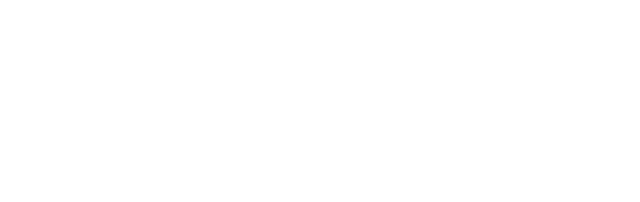

In [ ]:
# sanity preview: one batch
x_batch, y_batch = next(train_generator)
print("x_batch shape:", x_batch.shape)   # (batch_size, H, W, 3)
print("y_batch shape:", y_batch.shape)   # (batch_size, num_classes)
print("Batch label counts:", y_batch.sum(axis=0))
# show 3 image thumbnails (requires matplotlib)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,3))
for i in range(3):
    plt.subplot(1,3,i+1); plt.imshow((x_batch[i]+1)/2)  # inputs are preprocessed; simple rescale for display
    plt.axis('off')
plt.show()


In [ ]:
# Cell 6: Build EfficientNetB4 model and compile
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras import layers, models, optimizers
import tensorflow as tf

base_model = EfficientNetB4(include_top=False, input_shape=(*IMG_SIZE,3), weights='imagenet')
base_model.trainable = False

inputs = layers.Input(shape=(*IMG_SIZE,3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.45)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.summary()

opt = optimizers.Adamax(learning_rate=1e-3)
loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING)
model.compile(optimizer=opt, loss=loss, metrics=['accuracy'])


71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 380, 380, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 12, 12, 1792)   │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1792)           │         7,168 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       459,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,142,051 (69.21 MB)

 Trainable params: 464,132 (1.77 MB)

 Non-trainable params: 17,677,919 (67.44 MB)

In [ ]:
# Cell 7 (fixed): Callbacks and initial training (head only)
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping, CSVLogger
import os

checkpoint_path = os.path.join(MODEL_DIR, "efficientnetb4_best.keras")
csv_log = os.path.join(MODEL_DIR, "training_log.csv")

# Monitor training 'loss' because we have no val set.
callbacks = [
    ModelCheckpoint(checkpoint_path, monitor='loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    EarlyStopping(monitor='loss', patience=PATIENCE, restore_best_weights=True, verbose=1),
    CSVLogger(csv_log)
]

initial_epochs = max(1, int(EPOCHS * 0.6))

# Run training — NOTE: removed workers and use_multiprocessing (not supported in this runtime)
history = model.fit(
    train_generator,
    epochs=initial_epochs,
    class_weight=class_weights,
    callbacks=callbacks
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6737 - loss: 1.1343
Epoch 1: loss improved from inf to 0.95922, saving model to /content/drive/MyDrive/newDataset/Model/efficientnetb4_best.keras
286/286 ━━━━━━━━━━━━━━━━━━━━ 1968s 7s/step - accuracy: 0.6739 - loss: 1.1337 - learning_rate: 0.0010
Epoch 2/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 869ms/step - accuracy: 0.8011 - loss: 0.7675
Epoch 2: loss improved from 0.95922 to 0.75777, saving model to /content/drive/MyDrive/newDataset/Model/efficientnetb4_best.keras
286/286 ━━━━━━━━━━━━━━━━━━━━ 250s 875ms/step - accuracy: 0.8011 - loss: 0.7674 - learning_rate: 0.0010
Epoch 3/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 865ms/step - accuracy: 0.8217 - loss: 0.7136
Epoch 3: loss improved from 0.75777 to 0.70248, saving model to /content/drive/MyDrive/newDataset/Model/efficientnetb4_best.keras
286/286 ━━━━━━━━━━━━━━━━━━━━ 250s 871ms/step - accuracy: 0.8217 - loss: 0.7136 - learning_rate: 0.0010
Epoch 4/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 885

In [ ]:
# Cell 8 (corrected + safe): Fine-tune - unfreeze last FINE_TUNE_UNFREEZE_LAST layers and continue training
# Explanation: ensure initial_epoch starts at the next epoch (history.epoch[-1] + 1) so we don't re-run the last finished epoch.

# Inspect base model depth to help choose how many layers to unfreeze
num_layers = len(base_model.layers)
print("Base model layer count:", num_layers)
# Recommendation: try FINE_TUNE_UNFREEZE_LAST = 50 or 100 first (adjust if you have memory)
if 'FINE_TUNE_UNFREEZE_LAST' not in globals() or FINE_TUNE_UNFREEZE_LAST is None:
    FINE_TUNE_UNFREEZE_LAST = 50

unfreeze_from = max(0, num_layers - FINE_TUNE_UNFREEZE_LAST)

# Freeze earlier layers, unfreeze the last ones
for layer in base_model.layers[:unfreeze_from]:
    layer.trainable = False
for layer in base_model.layers[unfreeze_from:]:
    layer.trainable = True

# Recompile with a low learning rate for fine-tuning
from tensorflow.keras import optimizers
fine_lr = 1e-5
model.compile(optimizer=optimizers.Adam(learning_rate=fine_lr), loss=loss, metrics=['accuracy'])

# compute a safe starting epoch: next epoch after last trained epoch
if ('history' in globals() and hasattr(history, 'epoch') and len(history.epoch) > 0):
    start_epoch = history.epoch[-1] + 1
else:
    start_epoch = 0

# total number of epochs we will run (stop at EPOCHS)
total_target_epochs = EPOCHS
if start_epoch >= total_target_epochs:
    print("Warning: start_epoch >= total_target_epochs; nothing to run.")
else:
    print(f"Unfreezing layers from index {unfreeze_from} / {num_layers} (last {FINE_TUNE_UNFREEZE_LAST} layers).")
    print(f"Fine-tuning from epoch {start_epoch} up to {total_target_epochs - 1} (LR={fine_lr}).")

    history_fine = model.fit(
        train_generator,
        epochs=total_target_epochs,
        initial_epoch=start_epoch,
        class_weight=class_weights,
        callbacks=callbacks
    )


Base model layer count: 475
Unfreezing layers from index 425 / 475 (last 50 layers).
Fine-tuning from epoch 30 up to 49 (LR=1e-05).
Epoch 31/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8577 - loss: 0.6202
Epoch 31: loss did not improve from 0.49542
286/286 ━━━━━━━━━━━━━━━━━━━━ 353s 1s/step - accuracy: 0.8577 - loss: 0.6201 - learning_rate: 1.0000e-05
Epoch 32/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 908ms/step - accuracy: 0.8979 - loss: 0.5414
Epoch 32: loss did not improve from 0.49542
286/286 ━━━━━━━━━━━━━━━━━━━━ 260s 909ms/step - accuracy: 0.8979 - loss: 0.5414 - learning_rate: 1.0000e-05
Epoch 33/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 904ms/step - accuracy: 0.9020 - loss: 0.5367
Epoch 33: loss did not improve from 0.49542
286/286 ━━━━━━━━━━━━━━━━━━━━ 259s 905ms/step - accuracy: 0.9021 - loss: 0.5366 - learning_rate: 1.0000e-05
Epoch 34/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 893ms/step - accuracy: 0.9181 - loss: 0.5034
Epoch 34: loss did not improve from 0.49542
286/286 ━━━━━━━━━━━━━

In [ ]:
# Cell 1: Mount Drive and basic setup (run first)
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os, json, numpy as np, pandas as pd
import tensorflow as tf
from pathlib import Path

# Update these if you used different names
DRIVE_ROOT = "/content/drive/MyDrive"
DATA_ROOT = os.path.join(DRIVE_ROOT, "newDataset")
PREPRO_ROOT = os.path.join(DATA_ROOT, "preprocessed")
MODEL_DIR = os.path.join(DATA_ROOT, "Model")

# Basic training params you used earlier (ensure they match)
IMG_SIZE = (380, 380)   # must match preprocessing
BATCH_SIZE = 20

print("DATA_ROOT:", DATA_ROOT)
print("PREPRO_ROOT:", PREPRO_ROOT)
print("MODEL_DIR:", MODEL_DIR)

# Path to your uploaded research paper (for reference)
print("Research paper (local path):", "/mnt/data/researchPaper_faizal.pdf")


Mounted at /content/drive
DATA_ROOT: /content/drive/MyDrive/newDataset
PREPRO_ROOT: /content/drive/MyDrive/newDataset/preprocessed
MODEL_DIR: /content/drive/MyDrive/newDataset/Model
Research paper (local path): /mnt/data/researchPaper_faizal.pdf


In [ ]:
# Cell 2: Recreate test generator, load best model, predict on test set and save CSV
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
import os, numpy as np, pandas as pd

test_dir = os.path.join(PREPRO_ROOT, "test")
if not os.path.isdir(test_dir):
    raise FileNotFoundError(f"Test preprocessed folder not found: {test_dir}. Make sure preprocessing was done and files exist.")

test_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.efficientnet.preprocess_input)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Load best saved model - update file name if different
checkpoint_path = os.path.join(MODEL_DIR, "efficientnetb4_best.keras")
if not os.path.exists(checkpoint_path):
    # try alternative h5 extension if present
    alt = os.path.join(MODEL_DIR, "efficientnetb4_best.h5")
    if os.path.exists(alt):
        checkpoint_path = alt

print("Loading model from:", checkpoint_path)
model = load_model(checkpoint_path)
print("Model loaded.")

# Predict
test_steps = int(np.ceil(test_generator.samples / test_generator.batch_size))
probs = model.predict(test_generator, steps=test_steps, verbose=1)
preds = np.argmax(probs, axis=1)
true = test_generator.classes
filenames = test_generator.filenames

# map indices to class names
class_indices = test_generator.class_indices
inv_class_indices = {v:k for k,v in class_indices.items()}

# Build results dataframe and save
cols = ["filename", "true_label", "pred_label"] + [f"prob_{i}" for i in range(probs.shape[1])]
rows = []
for i, fname in enumerate(filenames):
    rows.append([fname, inv_class_indices[true[i]], inv_class_indices[preds[i]]] + [float(probs[i,j]) for j in range(probs.shape[1])])
results_df = pd.DataFrame(rows, columns=cols)
results_csv = os.path.join(MODEL_DIR, "test_predictions.csv")
results_df.to_csv(results_csv, index=False)
print("Saved predictions to:", results_csv)


Found 1311 images belonging to 4 classes.
Loading model from: /content/drive/MyDrive/newDataset/Model/efficientnetb4_best.keras
Model loaded.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


 1/66 ━━━━━━━━━━━━━━━━━━━━ 2:24:46 134s/step

KeyboardInterrupt: 